<a href="https://colab.research.google.com/github/delwin-c-raju/computational-physics-/blob/main/Miller_indices_%26_bragg's_law.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

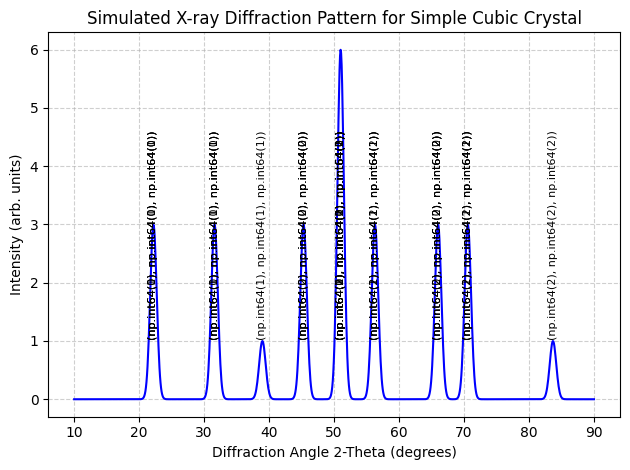

In [ ]:

# Import the necessary libraries
import numpy as np           # 'import' loads the library, 'numpy' handles numerical arrays, 'as np' gives it a short nickname
import matplotlib.pyplot as plt # 'matplotlib.pyplot' is the plotting module, 'as plt' is its standard nickname

# Define fundamental constants for the simulation
wavelength = 1.5406          # 'wavelength' variable stores X-ray wavelength in Angstroms (Copper K-alpha radiation)
a = 4.0                      # 'a' variable stores the cubic lattice parameter (unit cell size) in Angstroms
n = 1                        # 'n' variable is the order of reflection (integer 1 for first order)

# Generate a list of Miller indices (h, k, l)
# We will check combinations of h, k, l from 0 to 3
max_index = 3                # 'max_index' sets the upper limit for the Miller indices to explore
hkl_list = []                # 'hkl_list' initializes an empty list '[]' to store valid plane coordinates

# Nested loops to generate combinations
for h in range(max_index):   # 'for' starts a loop, 'h' is the variable, 'range()' generates numbers 0,1,2. ':' begins the block
    for k in range(max_index): # Inner loop for the 'k' index
        for l in range(max_index): # Inner loop for the 'l' index
            if h == 0 and k == 0 and l == 0: # 'if' checks a condition, 'and' requires all to be true. (0,0,0) is not a valid plane.
                continue     # 'continue' skips the rest of the loop for this specific (0,0,0) case
            hkl_list.append((h, k, l)) # '.append()' adds the tuple '(h,k,l)' to the end of our list

# Convert lists to NumPy arrays for fast, vectorized math
hkl_array = np.array(hkl_list) # 'np.array()' converts standard python list into a high-performance numerical array
h_arr = hkl_array[:, 0]        # '[:, 0]' slices the array: ':' means all rows, '0' means the first column (h values)
k_arr = hkl_array[:, 1]        # '[:, 1]' slices all rows, second column (k values)
l_arr = hkl_array[:, 2]        # '[:, 2]' slices all rows, third column (l values)

# Calculate interplanar spacing 'd' using vectorized arithmetic
# '**' is the power operator (squared), '+' adds them, 'np.sqrt()' takes the square root of the whole array at once
d_spacing = a / np.sqrt(h_arr**2 + k_arr**2 + l_arr**2)

# Calculate Bragg angles (theta)
# Bragg's law rearranged: sin(theta) = (n * wavelength) / (2 * d)
sin_theta = (n * wavelength) / (2 * d_spacing) # '/' is division, '*' is multiplication. Operations apply to the whole array.



# Calculate angles in radians, then convert to degrees
theta_rad = np.arcsin(sin_theta_valid)  # 'np.arcsin()' calculates the inverse sine (returns radians)
theta_deg = np.degrees(theta_rad)       # 'np.degrees()' converts radians to degrees
two_theta = 2 * theta_deg               # Experiments measure '2-theta', so we multiply the array by 2

# Simulate the continuous XRD spectrum using Gaussian peaks
x_angles = np.linspace(10, 90, 1000)    # 'np.linspace' generates 1000 evenly spaced points between 10 and 90 degrees
intensity = np.zeros_like(x_angles)     # 'np.zeros_like' creates an array of zeros the same size as x_angles

sigma = 0.5                             # 'sigma' controls the width of our simulated peaks (instrumental broadening)
for angle in two_theta:                 # Loop through each calculated valid 2-theta angle
    # Add a Gaussian curve centered at 'angle' to the total intensity array
    # 'np.exp()' is the exponential function, representing the bell curve shape
    intensity += np.exp(-0.5 * ((x_angles - angle) / sigma)**2)

# Plotting the results

plt.plot(x_angles, intensity, color='blue', label='Simulated XRD') # 'plt.plot()' draws the line graph using x and y arrays
plt.xlabel('Diffraction Angle 2-Theta (degrees)') # 'plt.xlabel()' sets the text label for the horizontal X axis
plt.ylabel('Intensity (arb. units)')    # 'plt.ylabel()' sets the text label for the vertical Y axis
plt.title('Simulated X-ray Diffraction Pattern for Simple Cubic Crystal') # 'plt.title()' adds the top heading
plt.grid(True, linestyle='--', alpha=0.6) # 'plt.grid()' adds gridlines. '--' makes them dashed, 'alpha' makes them semi-transparent

# Add text labels for the specific planes above their peaks
for i in range(len(two_theta)):         # Loop through indices 0 to the number of valid angles
    # 'plt.text()' places text on the plot at (x, y) coordinates. 'str()' converts numbers to text strings.
    plt.text(two_theta[i], 1.05, str(tuple(hkl_valid[i])), ha='center', fontsize=8, rotation=90)

plt.tight_layout()                      # 'plt.tight_layout()' automatically adjusts margins so nothing gets cut off
plt.show()                              # 'plt.show()' commands the notebook to render and display the final image